# Benchmark Run + Plot + Summary Notebook

This notebook provides an end-to-end benchmark workflow:
1. Build a benchmark name/path map from `examples/*.transact`
2. Run each benchmark using `cargo run -- {benchmark_path} {output_dir}`
3. Load generated JSON output from the selected output directory
4. Plot:
   - Cactus plot (sorted solved times, log-scale Y)
   - Strip plot (per-benchmark time distributions, single-point benchmarks supported)
5. Print a summary table similar to `benchmark_analysis.ipynb`

In [2]:
import json
import subprocess
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- User-configurable paths --------
PROJECT_ROOT = Path('.').resolve()
EXAMPLES_DIRS = [PROJECT_ROOT / 'benchmarks' / 'main',
                 PROJECT_ROOT / 'benchmarks' / 'benchbase',
                 PROJECT_ROOT / 'benchmarks' / 'scaling',]
OUTPUT_ROOT = PROJECT_ROOT / 'tmp_plot'   # Change this to any other output root

# Build benchmark map from all transact files in examples/
BENCHMARK_MAP = {
    p.stem: str(p)
    for p in sorted([file for directory in EXAMPLES_DIRS for file in directory.glob('*.transact')])
}

if not BENCHMARK_MAP:
    raise FileNotFoundError(f'No benchmark files found in {EXAMPLES_DIRS}')

print(f'Project root: {PROJECT_ROOT}')
print(f'Examples dir:  {EXAMPLES_DIRS}')
print(f'Output root:   {OUTPUT_ROOT}')
print('\nBenchmark map (name -> path):')
for name, path in BENCHMARK_MAP.items():
    print(f'  {name:20s} -> {path}')

Project root: /scratch/yanjunc6/FMitF_rs
Examples dir:  [PosixPath('/scratch/yanjunc6/FMitF_rs/benchmarks/main'), PosixPath('/scratch/yanjunc6/FMitF_rs/benchmarks/benchbase'), PosixPath('/scratch/yanjunc6/FMitF_rs/benchmarks/scaling')]
Output root:   /scratch/yanjunc6/FMitF_rs/tmp_plot

Benchmark map (name -> path):
  auctionmark          -> /scratch/yanjunc6/FMitF_rs/benchmarks/benchbase/auctionmark.transact
  smallbank            -> /scratch/yanjunc6/FMitF_rs/benchmarks/benchbase/smallbank.transact
  tatp                 -> /scratch/yanjunc6/FMitF_rs/benchmarks/benchbase/tatp.transact
  voter                -> /scratch/yanjunc6/FMitF_rs/benchmarks/benchbase/voter.transact
  ycsb                 -> /scratch/yanjunc6/FMitF_rs/benchmarks/benchbase/ycsb.transact
  rubis                -> /scratch/yanjunc6/FMitF_rs/benchmarks/main/rubis.transact
  social               -> /scratch/yanjunc6/FMitF_rs/benchmarks/main/social.transact
  tpcc                 -> /scratch/yanjunc6/FMitF_rs/benchma

In [3]:
# Set to True to execute benchmarks; set to False to reuse already generated outputs
RUN_BENCHMARKS = False

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
run_results = []

if RUN_BENCHMARKS:
    for bench_name, bench_path in BENCHMARK_MAP.items():
        # Skip JSON-only benchmarks that are added for analysis comparison.
        if bench_name == 'TPC-C no split' or str(bench_path).endswith('.json'):
            print(f"Skipping cargo run for JSON-only benchmark: {bench_name}")
            continue

        bench_output_dir = OUTPUT_ROOT / bench_name
        bench_output_dir.mkdir(parents=True, exist_ok=True)

        cmd = ['cargo', 'run', '--', bench_path, str(bench_output_dir), "--clear-cache"]
        print('\nRunning:', ' '.join(cmd))

        start = time.time()
        completed = subprocess.run(cmd, cwd=PROJECT_ROOT, capture_output=True, text=True)
        elapsed = time.time() - start

        run_results.append({
            'benchmark': bench_name,
            'return_code': completed.returncode,
            'elapsed_seconds': elapsed,
            'stdout_tail': '\n'.join(completed.stdout.splitlines()[-8:]),
            'stderr_tail': '\n'.join(completed.stderr.splitlines()[-8:]),
        })

        status = 'OK' if completed.returncode == 0 else 'FAIL'
        print(f'[{status}] {bench_name} finished in {elapsed:.2f}s')

    run_df = pd.DataFrame(run_results)
    print('\nRun summary:')
    display(run_df[['benchmark', 'return_code', 'elapsed_seconds']])
else:
    print('RUN_BENCHMARKS=False, skipping execution. Using existing outputs in OUTPUT_ROOT.')

RUN_BENCHMARKS=False, skipping execution. Using existing outputs in OUTPUT_ROOT.


In [4]:
def find_data_json(benchmark_output_dir: Path):
    """Find data.json directly or recursively under a benchmark output folder."""
    direct = benchmark_output_dir / 'data.json'
    if direct.exists():
        return direct

    matches = sorted(benchmark_output_dir.glob('**/data.json'))
    return matches[0] if matches else None

datasets = {}
missing = []

for bench_name in BENCHMARK_MAP:
    effective_name = bench_name

    bench_output_dir = OUTPUT_ROOT / bench_name
    json_path = find_data_json(bench_output_dir)

    if json_path is None or not Path(json_path).exists():
        missing.append((effective_name, str(json_path) if json_path is not None else str(OUTPUT_ROOT / bench_name)))
        continue

    with open(json_path, 'r') as f:
        datasets[effective_name] = json.load(f)

print('Loaded JSON datasets:')
for name in sorted(datasets):
    print(f'  {name}')

if missing:
    print('\nMissing data.json for:')
    for name, path_or_dir in missing:
        print(f'  {name:20s} (searched in {path_or_dir})')

if not datasets:
    raise RuntimeError('No datasets loaded. Run benchmarks first or check OUTPUT_ROOT.')

Loaded JSON datasets:
  auctionmark
  bench_001
  bench_010
  bench_020
  bench_030
  bench_040
  bench_050
  bench_060
  bench_070
  bench_080
  bench_090
  bench_100
  rubis
  smallbank
  social
  tatp
  tpcc
  voter
  ycsb


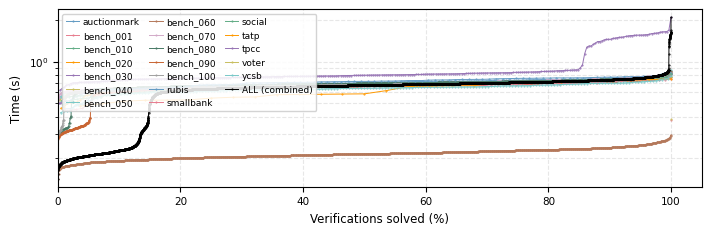

In [5]:
def extract_durations_seconds(data):
    verifications = data.get('c_edge_verifications', [])
    return [float(v['duration_ms']) / 1000.0 for v in verifications if 'duration_ms' in v]

durations_by_benchmark = {
    name: extract_durations_seconds(data)
    for name, data in datasets.items()
}

SHOW_COMBINED_CACTUS = True
CACTUS_MARKER = 'o'
CACTUS_MARKER_SIZE = 0.5
CACTUS_LINEWIDTH = 0.7

# ── Color palette (rooted in myblue / myred / mygreen / myorange) ──────
PALETTE = [
    '#619AC3',  # myblue    (97, 154, 195)
    '#E77C8E',  # myred     (231, 124, 142)
    '#61AC85',  # mygreen   (97, 172, 133)
    '#FF9900',  # myorange  (255, 153, 0)
    '#9673B4',  # purple
    '#C8BE5F',  # olive
    '#78C8C8',  # teal
    '#B4785A',  # brown
    '#D2AAC8',  # lavender
    '#467864',  # dark teal
    '#C86432',  # rust
    '#A0A0A0',  # gray
]

# ── Figure: A4 text-width, compact height ──────────────────────────────
fig_w = 7.0                # ≈ A4 text width (inches)
fig_h = fig_w * 0.32       # ~1/3 of width → fits 1/4–2/5 requirement
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

LABEL_FS  = 8.5
TICK_FS   = 7.5
LEGEND_FS = 6.5

# ── Per-benchmark lines (normalized x-axis → percentage) ──────────────
active = sorted(n for n in durations_by_benchmark
                if len(durations_by_benchmark[n]) > 0)

for idx, name in enumerate(active):
    times = np.array(sorted(durations_by_benchmark[name]), dtype=float)
    pct   = np.arange(1, len(times) + 1) / len(times) * 100.0   # ← key change
    ax.plot(pct, times,
            linewidth=CACTUS_LINEWIDTH,
            marker=CACTUS_MARKER, markersize=CACTUS_MARKER_SIZE,
            color=PALETTE[idx % len(PALETTE)],
            label=name)

# ── Combined cactus line ───────────────────────────────────────────────
if SHOW_COMBINED_CACTUS:
    combined = sorted(t for ts in durations_by_benchmark.values() for t in ts)
    if combined:
        combined = np.asarray(combined, dtype=float)
        pct = np.arange(1, len(combined) + 1) / len(combined) * 100.0
        ax.plot(pct, combined,
                linewidth=CACTUS_LINEWIDTH,
                marker=CACTUS_MARKER, markersize=CACTUS_MARKER_SIZE,
                color='black',
                label='ALL (combined)')

# ── Axes, grid, no title ──────────────────────────────────────────────
ax.set_yscale('log')
ax.set_xlim(0, 105)
ax.set_xlabel('Verifications solved (%)', fontsize=LABEL_FS)
ax.set_ylabel('Time (s)',                 fontsize=LABEL_FS)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
ax.grid(True, which='both', linestyle='--', alpha=0.3)

# ── Compact legend (multi-column, upper-left where plot is empty) ─────
ax.legend(
    fontsize=LEGEND_FS,
    ncol=3,
    loc='upper left',
    framealpha=0.85,
    borderpad=0.4,
    handlelength=1.5,
    handletextpad=0.4,
    columnspacing=1.0,
)

fig.tight_layout(pad=0.3)
fig.savefig(OUTPUT_ROOT / 'cactus_plot.pdf', bbox_inches='tight')
plt.show()

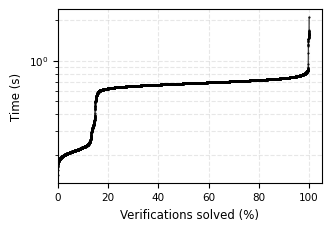

In [6]:
def extract_durations_seconds(data):
    verifications = data.get('c_edge_verifications', [])
    return [float(v['duration_ms']) / 1000.0 for v in verifications if 'duration_ms' in v]

durations_by_benchmark = {
    name: extract_durations_seconds(data)
    for name, data in datasets.items()
}

CACTUS_MARKER = 'o'
CACTUS_MARKER_SIZE = 0.5
CACTUS_LINEWIDTH = 0.7

# ── Figure: A4 text-width, compact height ──────────────────────────────
fig_w = 3.2                # ≈ ~1/3 A4 text width (inches)
fig_h = 2.2                # ~1/3 A4 text width (inches)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

LABEL_FS  = 8.5
TICK_FS   = 7.5
LEGEND_FS = 6.5

# ── Per-benchmark lines (normalized x-axis → percentage) ──────────────
active = sorted(n for n in durations_by_benchmark
                if len(durations_by_benchmark[n]) > 0)

combined = sorted(t for ts in durations_by_benchmark.values() for t in ts)
if combined:
    combined = np.asarray(combined, dtype=float)
    pct = np.arange(1, len(combined) + 1) / len(combined) * 100.0
    ax.plot(pct, combined,
            linewidth=CACTUS_LINEWIDTH,
            marker=CACTUS_MARKER, markersize=CACTUS_MARKER_SIZE,
            color='black')

# ── Axes, grid, no title ──────────────────────────────────────────────
ax.set_yscale('log')
ax.set_xlim(0, 105)
ax.set_xlabel('Verifications solved (%)', fontsize=LABEL_FS)
ax.set_ylabel('Time (s)',                 fontsize=LABEL_FS)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
ax.grid(True, which='both', linestyle='--', alpha=0.3)

# ── Compact legend (multi-column, upper-left where plot is empty) ─────
# ax.legend(
#     fontsize=LEGEND_FS,
#     ncol=3,
#     loc='upper left',
#     framealpha=0.85,
#     borderpad=0.4,
#     handlelength=1.5,
#     handletextpad=0.4,
#     columnspacing=1.0,
# )

fig.tight_layout(pad=0.3)
fig.savefig(OUTPUT_ROOT / 'cactus_plot.pdf', bbox_inches='tight')
plt.show()

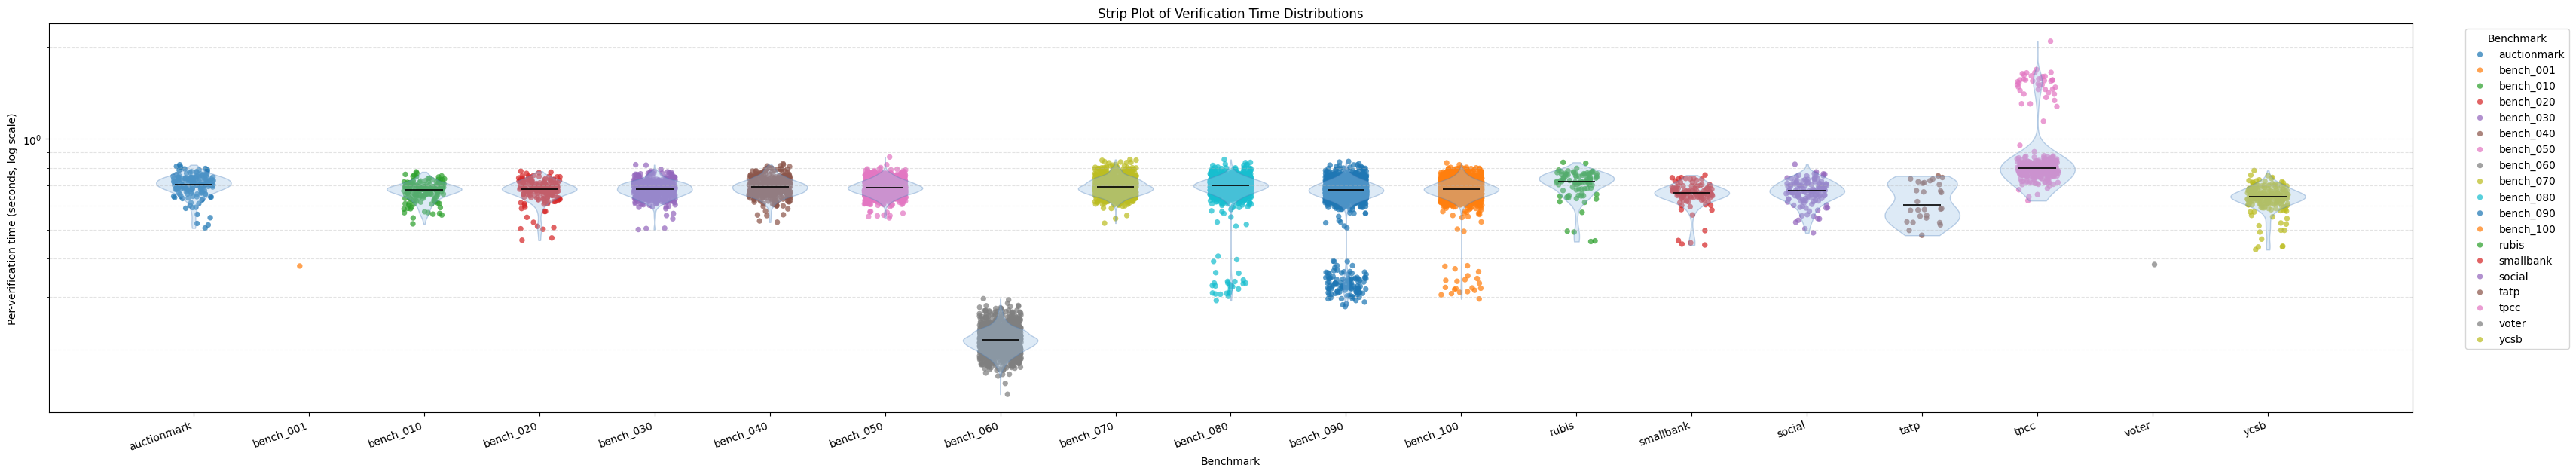

In [7]:
# Strip plot (manual jittered scatter), robust even when a benchmark has only one point
benchmarks = sorted(durations_by_benchmark.keys())
rng = np.random.default_rng(42)

# Overlay options: 'none', 'box', 'violin'
OVERLAY_MODE = 'violin'
SHOW_POINTS = True

fig, ax = plt.subplots(figsize=(max(10, 1.8 * len(benchmarks)), 6.4))

overlay_positions = []
overlay_values = []

for i, bench in enumerate(benchmarks, start=1):
    times = np.array(durations_by_benchmark[bench], dtype=float)
    if len(times) == 0:
        continue

    if SHOW_POINTS:
        x_jitter = i + rng.uniform(-0.18, 0.18, size=len(times))
        ax.scatter(x_jitter, times, s=28, alpha=0.72, edgecolors='none', label=bench)

    # Keep only groups with >1 point for distribution overlays
    if len(times) > 1:
        overlay_positions.append(i)
        overlay_values.append(times)

if OVERLAY_MODE == 'box' and overlay_values:
    bp = ax.boxplot(
        overlay_values,
        positions=overlay_positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.4},
    )
    for patch in bp['boxes']:
        patch.set_facecolor('#9fc5e8')
        patch.set_alpha(0.35)

elif OVERLAY_MODE == 'violin' and overlay_values:
    vp = ax.violinplot(
        overlay_values,
        positions=overlay_positions,
        widths=0.65,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )
    for body in vp['bodies']:
        body.set_facecolor('#9fc5e8')
        body.set_edgecolor('#4f81bd')
        body.set_alpha(0.35)
    if 'cmedians' in vp:
        vp['cmedians'].set_color('black')
        vp['cmedians'].set_linewidth(1.2)

ax.set_xticks(np.arange(1, len(benchmarks) + 1))
ax.set_xticklabels(benchmarks, rotation=20, ha='right')
ax.set_yscale('log')
ax.set_xlabel('Benchmark')
ax.set_ylabel('Per-verification time (seconds, log scale)')
ax.set_title('Strip Plot of Verification Time Distributions')
ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.35)

# Avoid duplicate legend entries for points
if SHOW_POINTS:
    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys(), title='Benchmark', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'strip_plot.pdf')
plt.show()

In [8]:
summary_rows = []

# Keep report names aligned with what is actually loaded in datasets.
report_benchmarks = sorted(datasets.keys())

for benchmark_name in report_benchmarks:
    data = datasets.get(benchmark_name)
    verifications = data.get('c_edge_verifications', []) if data is not None else []
    summary = data.get('summary', {}) if data is not None else {}
    
    sc_cycle_removed = summary.get('verification_pre_sc_cycle_count', 0) - summary.get('verification_post_sc_cycle_count', 0)
    merges_removed = summary.get('verification_pre_merged_node_count', 0) - summary.get('verification_post_merged_node_count', 0)
    merge_node_size_pre = summary.get('verification_pre_average_merged_node_size', 0)
    merge_node_size_post = summary.get('verification_post_average_merged_node_size', 0)
    merge_node_size_reduction = (merge_node_size_pre - merge_node_size_post) if merge_node_size_pre > 0 else 0.0
    
    # Conflict statistics
    pre_total_conflicts = summary.get('verification_pre_total_conflicts', 0)
    pre_avg_conflicts = summary.get('verification_pre_average_conflicts_per_hop', 0.0)
    post_total_conflicts = summary.get('verification_post_total_conflicts', 0)
    post_avg_conflicts = summary.get('verification_post_average_conflicts_per_hop', 0.0)
    avg_conflicts_reduction = (pre_avg_conflicts - post_avg_conflicts) if pre_avg_conflicts > 0 else 0.0

    total_count = len(verifications)
    pass_count = sum(1 for v in verifications if v.get('result') == 'Pass')
    error_count = sum(1 for v in verifications if v.get('result') == 'Error')
    timeout_count = sum(1 for v in verifications if v.get('result') == 'Timeout')
    
    commutative_rate = (pass_count / total_count * 100.0) if total_count > 0 else 0.0

    # Use verification stage time from summary
    verification_time_ms = summary.get('stage_verification_ms', 0.0)
    verification_time_s = verification_time_ms / 1000.0
    
    if total_count > 0:
        durations = np.array([float(v['duration_ms']) / 1000.0 for v in verifications], dtype=float)
        median_time = float(np.median(durations))
        p95_time = float(np.percentile(durations, 95))
        max_time = float(np.max(durations))
    else:
        median_time = 0.0
        p95_time = 0.0
        max_time = 0.0

    summary_rows.append({
        'Benchmark': benchmark_name,
        'Total C-Edges': total_count,
        'Commutative (Pass)': pass_count,
        'Non-Commutative': error_count,
        'Timeouts': timeout_count,
        'Commutative Rate (%)': f'{commutative_rate:.1f}',
        'Verification Stage Time (s)': f'{verification_time_s:.2f}',
        'Median Time (s)': f'{median_time:.4f}',
        'P95 Time (s)': f'{p95_time:.4f}',
        'Max Time (s)': f'{max_time:.4f}',
        'SC Cycles Removed': sc_cycle_removed,
        'Merges Removed': merges_removed,
        'Merge Node Size Pre': f'{merge_node_size_pre:.2f}',
        'Merge Node Size Post': f'{merge_node_size_post:.2f}',
        'Merge Node Size Reduction': f'{merge_node_size_reduction:.2f}',
        'Pre-Verification Conflicts': pre_total_conflicts,
        'Pre-Verification Avg Conflicts/Hop': f'{pre_avg_conflicts:.2f}',
        'Post-Verification Conflicts': post_total_conflicts,
        'Post-Verification Avg Conflicts/Hop': f'{post_avg_conflicts:.2f}',
        'Avg Conflicts Reduction/Hop': f'{avg_conflicts_reduction:.2f}',
    })

summary_df = pd.DataFrame(summary_rows)[[
    'Benchmark',
    'Total C-Edges',
    'Commutative (Pass)',
    # 'Non-Commutative',
    #'Timeouts',
    'Commutative Rate (%)',
    'Verification Stage Time (s)',
    # 'Median Time (s)',
    # 'P95 Time (s)',
    'Max Time (s)',
    # 'SC Cycles Removed',
    'Merges Removed',
    # 'Merge Node Size Pre',
    # 'Merge Node Size Post',
    # 'Merge Node Size Reduction',
    # 'Pre-Verification Conflicts',
    # 'Pre-Verification Avg Conflicts/Hop',
    # 'Post-Verification Conflicts',
    # 'Post-Verification Avg Conflicts/Hop',
    'Avg Conflicts Reduction/Hop',
]]

print('\n' + '=' * 200)
print('BENCHMARK SUMMARY')
print('=' * 200)
print(summary_df.to_string(index=False))
print('=' * 200)

print('\nDetailed breakdown:\n')
for row in summary_rows:
    print(f"{row['Benchmark']}:")
    print(f"  Total C-edges:           {row['Total C-Edges']}")
    print(f"  Commutative (Pass):      {row['Commutative (Pass)']}")
    print(f"  Non-Commutative:         {row['Non-Commutative']}")
    print(f"  Timeouts:                {row['Timeouts']}")
    print(f"  Commutative Rate:        {row['Commutative Rate (%)']}%")
    print(f"  Verification Stage Time: {row['Verification Stage Time (s)']} seconds")
    print(f"  Median Time:             {row['Median Time (s)']} seconds")
    print(f"  P95 Time:                {row['P95 Time (s)']} seconds")
    print(f"  Max Time:                {row['Max Time (s)']} seconds\n")
    print(f"  SC Cycles Removed:       {row['SC Cycles Removed']}")
    print(f"  Merges Removed:          {row['Merges Removed']}")
    print(f"  Merge Node Size Pre:     {row['Merge Node Size Pre']}")
    print(f"  Merge Node Size Post:    {row['Merge Node Size Post']}")
    print(f"  Merge Node Size Reduction: {row['Merge Node Size Reduction']}")
    print(f"  Pre-Verification Conflicts: {row['Pre-Verification Conflicts']}")
    print(f"  Pre-Verification Avg Conflicts/Hop: {row['Pre-Verification Avg Conflicts/Hop']}")
    print(f"  Post-Verification Conflicts: {row['Post-Verification Conflicts']}")
    print(f"  Post-Verification Avg Conflicts/Hop: {row['Post-Verification Avg Conflicts/Hop']}")
    print(f"  Avg Conflicts Reduction/Hop: {row['Avg Conflicts Reduction/Hop']}\n")



BENCHMARK SUMMARY
  Benchmark  Total C-Edges  Commutative (Pass) Commutative Rate (%) Verification Stage Time (s) Max Time (s)  Merges Removed Avg Conflicts Reduction/Hop
auctionmark            156                  34                 21.8                        6.46       0.8189               0                        1.31
  bench_001              1                   0                  0.0                        0.51       0.3788               0                        0.00
  bench_010            167                  50                 29.9                        6.41       0.7759               0                        2.27
  bench_020            191                  78                 40.8                        7.70       0.7798               2                        1.91
  bench_030            447                 200                 44.7                       17.04       0.8191               0                        3.18
  bench_040            454                 195                 

## Factor-Style Analysis Across All Datasets

This section mirrors the plotting style used in `factor_analysis.ipynb`, but runs directly inside this notebook.

- It scans all available `data.json` files in the workspace.
- It includes configurable include/exclude filters so you can remove datasets later without changing the logic.
- It builds one per-c-edge table and one per-dataset summary table for plotting.

In [9]:
import re
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# -------- Plot style (matching factor_analysis palette and look) --------
PASS_COLOR = '#61AC85'   # mygreen
ERROR_COLOR = '#E77C8E'  # myred
ORANGE = '#FF9900'       # myorange
BLUE = '#619AC3'         # myblue
GRAY_LIGHT = '#CCCCCC'
POINT_ALPHA = 0.6
sns.set_theme(style='whitegrid', font_scale=1.0)

# -------- Dataset selection controls (pipeline datasets only) --------
# Use benchmark names from BENCHMARK_MAP keys for include/exclude.
PIPELINE_INCLUDE_NAMES = ['*']
PIPELINE_EXCLUDE_NAMES = []


def _safe_float(v):
    try:
        return float(v)
    except Exception:
        return np.nan


def _read_text_safe(path: Path):
    try:
        return path.read_text(encoding='utf-8', errors='ignore')
    except Exception:
        return ''


def _estimate_schema_size_from_transact(transact_path: Path):
    txt = _read_text_safe(transact_path)
    if not txt:
        return np.nan
    patterns = [r'^\s*table\b', r'^\s*relation\b', r'^\s*entity\b']
    total = 0
    for pat in patterns:
        total += len(re.findall(pat, txt, flags=re.MULTILINE))
    return float(total) if total > 0 else np.nan


def _estimate_template_count_from_transact(transact_path: Path):
    txt = _read_text_safe(transact_path)
    if not txt:
        return np.nan
    patterns = [r'^\s*transaction\b', r'^\s*txn\b', r'^\s*procedure\b', r'^\s*function\b']
    total = 0
    for pat in patterns:
        total += len(re.findall(pat, txt, flags=re.MULTILINE))
    return float(total) if total > 0 else np.nan


def _first_not_nan(values):
    for v in values:
        fv = _safe_float(v)
        if not np.isnan(fv):
            return fv
    return np.nan


def _matches_any_glob(name, patterns):
    import fnmatch
    return any(fnmatch.fnmatch(name, p) for p in patterns)


def find_data_json(benchmark_output_dir: Path):
    direct = benchmark_output_dir / 'data.json'
    if direct.exists():
        return direct
    matches = sorted(benchmark_output_dir.glob('**/data.json'))
    return matches[0] if matches else None


# Build datasets from this notebook's benchmark pipeline outputs only.
# If `datasets` already exists from earlier cells, reuse it directly.
if 'datasets' in globals() and isinstance(datasets, dict) and len(datasets) > 0:
    pipeline_datasets = dict(datasets)
else:
    pipeline_datasets = {}
    for bench_name in BENCHMARK_MAP:
        out_dir = OUTPUT_ROOT / bench_name
        json_path = find_data_json(out_dir)
        if json_path is None or not json_path.exists():
            continue
        with open(json_path, 'r') as f:
            pipeline_datasets[bench_name] = json.load(f)

selected_names = sorted(
    (
        n for n in pipeline_datasets.keys()
        if _matches_any_glob(n, PIPELINE_INCLUDE_NAMES) and n not in set(PIPELINE_EXCLUDE_NAMES)
    )
)

rows_edge = []
rows_dataset = []

for dataset_name in selected_names:
    payload = pipeline_datasets[dataset_name]
    summary = payload.get('summary', {}) or {}
    edges = payload.get('c_edge_verifications', []) or []
    input_file = payload.get('input_file', None)

    input_path = None
    if isinstance(input_file, str) and input_file.strip():
        cand = Path(input_file)
        if cand.exists():
            input_path = cand
        else:
            cand2 = (PROJECT_ROOT / input_file).resolve()
            if cand2.exists():
                input_path = cand2

    hop_count = _first_not_nan([
        summary.get('hop_count'),
        summary.get('verification_pre_merged_hop_count'),
        summary.get('verification_post_merged_hop_count'),
    ])

    schema_size = _first_not_nan([
        summary.get('instance_count'),
        summary.get('schema_size'),
        summary.get('table_count'),
        summary.get('tables_count'),
        summary.get('num_tables'),
    ])

    txn_template_count = _first_not_nan([
        summary.get('function_count'),
        summary.get('transaction_template_count'),
        summary.get('num_transactions'),
        summary.get('transaction_count'),
    ])

    if np.isnan(schema_size) and input_path is not None:
        schema_size = _estimate_schema_size_from_transact(input_path)
    if np.isnan(txn_template_count) and input_path is not None:
        txn_template_count = _estimate_template_count_from_transact(input_path)

    # Required by your update: use verification stage total wall-clock time.
    stage_verification_ms = _safe_float(summary.get('stage_verification_ms'))
    if np.isnan(stage_verification_ms):
        stage_verification_ms = _safe_float(sum(_safe_float(e.get('duration_ms')) for e in edges if not np.isnan(_safe_float(e.get('duration_ms')))))

    pass_count = sum(1 for e in edges if e.get('result') == 'Pass')
    error_count = sum(1 for e in edges if e.get('result') == 'Error')
    timeout_count = sum(1 for e in edges if e.get('result') == 'Timeout')

    rows_dataset.append({
        'dataset': dataset_name,
        'data_json_path': str((OUTPUT_ROOT / dataset_name / 'data.json').relative_to(PROJECT_ROOT)) if (OUTPUT_ROOT / dataset_name / 'data.json').exists() else '',
        'input_file': str(input_path) if input_path is not None else str(input_file),
        'num_c_edges': len(edges),
        'pass_count': pass_count,
        'error_count': error_count,
        'timeout_count': timeout_count,
        'commutative_rate_pct': (100.0 * pass_count / len(edges)) if len(edges) else np.nan,
        'verification_stage_ms': stage_verification_ms,
        'hop_count': hop_count,
        'schema_size': schema_size,
        'txn_template_count': txn_template_count,
        'sc_c_edges': _safe_float(summary.get('sc_c_edges')),
        'simplified_sc_c_edges': _safe_float(summary.get('simplified_sc_c_edges')),
    })

    for e in edges:
        rows_edge.append({
            'dataset': dataset_name,
            'result': e.get('result', 'Unknown'),
            'duration_ms': _safe_float(e.get('duration_ms')),
            'boogie_file_len': _safe_float(e.get('boogie_file_len')),
            'real_procedure_len': _safe_float(e.get('real_procedure_len')),
            'branch_count': _safe_float(e.get('branch_count')),
            'db_read_count': _safe_float(e.get('db_read_count')),
            'db_write_count': _safe_float(e.get('db_write_count')),
            'db_total_ops': _safe_float(e.get('db_read_count')) + _safe_float(e.get('db_write_count')),
            'source_hop_id': _safe_float(e.get('source_hop_id')),
            'target_hop_id': _safe_float(e.get('target_hop_id')),
            'max_primary_key_count': _safe_float(e.get('max_primary_key_count')),
        })

df_all_cedge = pd.DataFrame(rows_edge)
df_all_dataset = pd.DataFrame(rows_dataset)

print(f'Pipeline datasets available: {len(pipeline_datasets)}')
print(f'Pipeline datasets selected: {len(df_all_dataset)}')
print(f'Selected c-edge records: {len(df_all_cedge)}')

if df_all_dataset.empty or df_all_cedge.empty:
    raise RuntimeError('No pipeline datasets loaded after include/exclude filtering.')

for col in [
    'duration_ms', 'boogie_file_len', 'real_procedure_len', 'branch_count',
    'db_read_count', 'db_write_count', 'db_total_ops',
    'max_primary_key_count',
]:
    if col in df_all_cedge.columns:
        df_all_cedge[col] = pd.to_numeric(df_all_cedge[col], errors='coerce')

for col in ['verification_stage_ms', 'hop_count', 'schema_size', 'txn_template_count', 'num_c_edges']:
    if col in df_all_dataset.columns:
        df_all_dataset[col] = pd.to_numeric(df_all_dataset[col], errors='coerce')

print('\nSelected pipeline datasets (table):')
display(df_all_dataset[['dataset', 'num_c_edges', 'verification_stage_ms', 'hop_count', 'schema_size', 'txn_template_count']].sort_values('dataset'))

Pipeline datasets available: 19
Pipeline datasets selected: 19
Selected c-edge records: 11467

Selected pipeline datasets (table):


,dataset,num_c_edges,verification_stage_ms,hop_count,schema_size,txn_template_count
0,auctionmark,156,6464.827254,15.0,2.0,51.0
1,bench_001,1,509.180593,2.0,2.0,19.0
2,bench_010,167,6410.821657,12.0,2.0,32.0
3,bench_020,191,7697.901563,23.0,2.0,49.0
4,bench_030,447,17044.359764,34.0,2.0,61.0
5,bench_040,454,17974.331188,43.0,2.0,77.0
6,bench_050,1010,38011.368217,57.0,2.0,85.0
7,bench_060,1532,19407.552987,66.0,2.0,93.0
8,bench_070,1087,41918.674363,74.0,2.0,106.0
9,bench_080,1287,49087.584731,90.0,2.0,123.0


In [10]:
def _spearman_safe(x, y):
    valid = pd.Series(x).notna() & pd.Series(y).notna()
    if valid.sum() < 3:
        return np.nan, np.nan, int(valid.sum())
    x_valid = pd.Series(x)[valid]
    y_valid = pd.Series(y)[valid]
    if x_valid.nunique(dropna=True) <= 1 or y_valid.nunique(dropna=True) <= 1:
        return np.nan, np.nan, int(valid.sum())
    rho, p = stats.spearmanr(x_valid, y_valid)
    return float(rho), float(p), int(valid.sum())


def plot_factor_style_three_panel(df, x_col, x_label, out_pdf):
    """Match factor_analysis style: scatter + rolling trend + distribution panel (c-edge y=duration_ms)."""
    local = df.copy()
    local = local[pd.notna(local[x_col]) & pd.notna(local['duration_ms'])]
    if local.empty:
        print(f'[SKIP] {x_col}: no valid rows')
        return

    fig, axes = plt.subplots(1, 3, figsize=(24, 5))
    x = local[x_col]
    y = local['duration_ms']
    mask_pass = local['result'] == 'Pass'
    mask_error = local['result'] == 'Error'

    axes[0].scatter(x[mask_pass], y[mask_pass], c=PASS_COLOR, alpha=POINT_ALPHA, s=15, edgecolors='none', label='Pass')
    axes[0].scatter(x[mask_error], y[mask_error], c=ERROR_COLOR, alpha=POINT_ALPHA, s=15, edgecolors='none', label='Error')
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel('duration_ms')
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.2)
    axes[0].set_title(f'{x_label} vs Verification Time')
    axes[0].legend(loc='upper left')

    rho, p, n = _spearman_safe(x, y)
    axes[0].text(
        0.02, 0.95,
        f'Spearman rho = {rho:.3f}\np = {p:.2e}\nn = {n}',
        transform=axes[0].transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
    )

    sort_idx = np.argsort(x.values)
    x_sorted = x.values[sort_idx]
    y_sorted = y.values[sort_idx]
    window = max(3, len(local) // 12)
    rolling_mean = pd.Series(y_sorted).rolling(window=window, center=True).mean().values

    axes[1].plot(x_sorted, y_sorted, 'o', alpha=0.15, markersize=3, color=GRAY_LIGHT)
    axes[1].plot(x_sorted, rolling_mean, '-', color=ORANGE, linewidth=2.2, label=f'rolling avg (n={window})')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel('duration_ms')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.2)
    axes[1].set_title('Trend: Rolling Average')
    axes[1].legend()

    x_non_na = x.dropna()
    axes[2].hist(x_non_na, bins=30, edgecolor='black', alpha=0.7, color=BLUE)
    axes[2].set_xlabel(x_label)
    axes[2].set_ylabel('count')
    axes[2].set_title(f'{x_label} Distribution')
    if len(x_non_na) > 0:
        x_mean = float(x_non_na.mean())
        axes[2].axvline(x_mean, color=ORANGE, linestyle='--', label=f'mean={x_mean:.2f}')
        axes[2].legend()

    fig.tight_layout()
    fig.savefig(out_pdf, dpi=150, format='pdf')
    plt.show()
    print(f'Saved {out_pdf}')


def plot_dataset_wallclock_three_panel(df, x_col, x_label, out_pdf):
    """Factor-analysis style on dataset-level points with y=verification_stage_ms."""
    local = df.copy()
    local = local[pd.notna(local[x_col]) & pd.notna(local['verification_stage_ms'])]
    if local.empty:
        print(f'[SKIP] {x_col}: no valid rows')
        return

    fig, axes = plt.subplots(1, 3, figsize=(24, 5))
    x = local[x_col]
    y = local['verification_stage_ms']

    axes[0].scatter(x, y, c=BLUE, alpha=0.75, s=48, edgecolors='none')
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel('verification_stage_ms (wall-clock)')
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.2)
    axes[0].set_title(f'{x_label} vs Verification Stage Wall-Clock')

    rho, p, n = _spearman_safe(x, y)
    axes[0].text(
        0.02, 0.95,
        f'Spearman rho = {rho:.3f}\np = {p:.2e}\nn = {n}',
        transform=axes[0].transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
    )

    sort_idx = np.argsort(x.values)
    x_sorted = x.values[sort_idx]
    y_sorted = y.values[sort_idx]
    window = max(2, len(local) // 4)
    rolling_mean = pd.Series(y_sorted).rolling(window=window, center=True).mean().values

    axes[1].plot(x_sorted, y_sorted, 'o', alpha=0.2, markersize=4, color=GRAY_LIGHT)
    axes[1].plot(x_sorted, rolling_mean, '-', color=ORANGE, linewidth=2.2, label=f'rolling avg (n={window})')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel('verification_stage_ms (wall-clock)')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.2)
    axes[1].set_title('Trend: Rolling Average')
    axes[1].legend()

    x_non_na = x.dropna()
    axes[2].hist(x_non_na, bins=min(20, max(5, len(x_non_na))), edgecolor='black', alpha=0.7, color=BLUE)
    axes[2].set_xlabel(x_label)
    axes[2].set_ylabel('count')
    axes[2].set_title(f'{x_label} Distribution')
    if len(x_non_na) > 0:
        x_mean = float(x_non_na.mean())
        axes[2].axvline(x_mean, color=ORANGE, linestyle='--', label=f'mean={x_mean:.2f}')
        axes[2].legend()

    fig.tight_layout()
    fig.savefig(out_pdf, dpi=150, format='pdf')
    plt.show()
    print(f'Saved {out_pdf}')


def plot_result_distribution_2x2(df, out_pdf):
    """Match factor_analysis Theme 4 style."""
    local = df.copy()
    pass_df = local[local['result'] == 'Pass']['duration_ms'].dropna()
    error_df = local[local['result'] == 'Error']['duration_ms'].dropna()

    if len(pass_df) == 0 or len(error_df) == 0:
        print('[SKIP] Theme 4: Need both Pass and Error points to plot comparison.')
        return

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    sns.kdeplot(pass_df, ax=axes[0, 0], color=PASS_COLOR, label='Pass', fill=True, alpha=0.3)
    sns.kdeplot(error_df, ax=axes[0, 0], color=ERROR_COLOR, label='Error', fill=True, alpha=0.3)
    axes[0, 0].set_xlabel('duration_ms')
    axes[0, 0].set_ylabel('density')
    axes[0, 0].set_title('KDE: Time Distribution by Result')
    axes[0, 0].legend()

    axes[0, 1].hist(pass_df, bins=20, alpha=0.6, color=PASS_COLOR, label='Pass', density=True)
    axes[0, 1].hist(error_df, bins=20, alpha=0.6, color=ERROR_COLOR, label='Error', density=True)
    axes[0, 1].set_xlabel('duration_ms (log)')
    axes[0, 1].set_xscale('log')
    axes[0, 1].set_ylabel('density')
    axes[0, 1].set_title('Histogram (log X): Time Distribution')
    axes[0, 1].legend()

    bp = axes[1, 0].boxplot(
        [pass_df.values, error_df.values],
        tick_labels=[f'Pass ({len(pass_df)})', f'Error ({len(error_df)})'],
        patch_artist=True,
    )
    bp['boxes'][0].set_facecolor(PASS_COLOR)
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor(ERROR_COLOR)
    bp['boxes'][1].set_alpha(0.6)
    axes[1, 0].set_ylabel('duration_ms')
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_title('Box Plot: Pass vs Error')

    parts = axes[1, 1].violinplot([pass_df.values, error_df.values], showmeans=False, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(PASS_COLOR if i == 0 else ERROR_COLOR)
        pc.set_alpha(0.5)
    axes[1, 1].set_xticks([1, 2])
    axes[1, 1].set_xticklabels(['Pass', 'Error'])
    axes[1, 1].set_ylabel('duration_ms')
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_title('Violin Plot: Time Distribution')

    stat_val, stat_p = stats.mannwhitneyu(pass_df, error_df, alternative='two-sided')
    axes[0, 1].text(
        0.95, 0.95,
        f'Mann-Whitney U:\nU = {stat_val:.0f}, p = {stat_p:.2e}',
        transform=axes[0, 1].transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(boxstyle='round', facecolor='#B8D4E8', alpha=0.5),
    )

    fig.suptitle('Theme 4: Result -> Time Distribution', fontsize=15, y=0.98)
    fig.tight_layout()
    fig.savefig(out_pdf, dpi=150, format='pdf')
    plt.show()
    print(f'Saved {out_pdf}')
    print(f'Mann-Whitney U: U = {stat_val:.0f}, p = {stat_p:.2e}')
    print(f'Pass:  mean={pass_df.mean():.1f}ms, median={pass_df.median():.1f}ms, n={len(pass_df)}')
    print(f'Error: mean={error_df.mean():.1f}ms, median={error_df.median():.1f}ms, n={len(error_df)}')

Figure output directory: /scratch/yanjunc6/FMitF_rs/tmp_plot/factor_style_plots


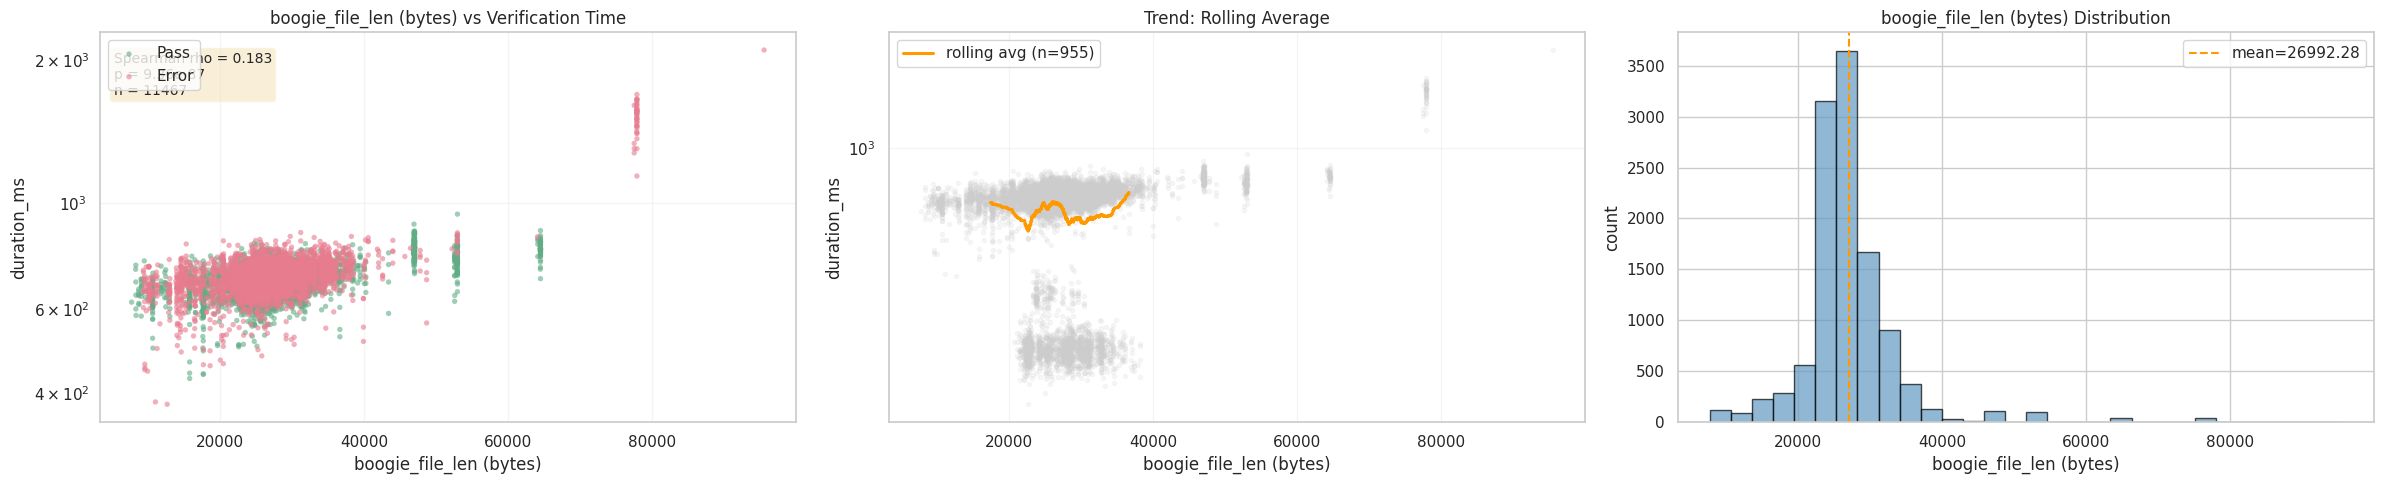

Saved /scratch/yanjunc6/FMitF_rs/tmp_plot/factor_style_plots/theme1_boogie_vs_time.pdf


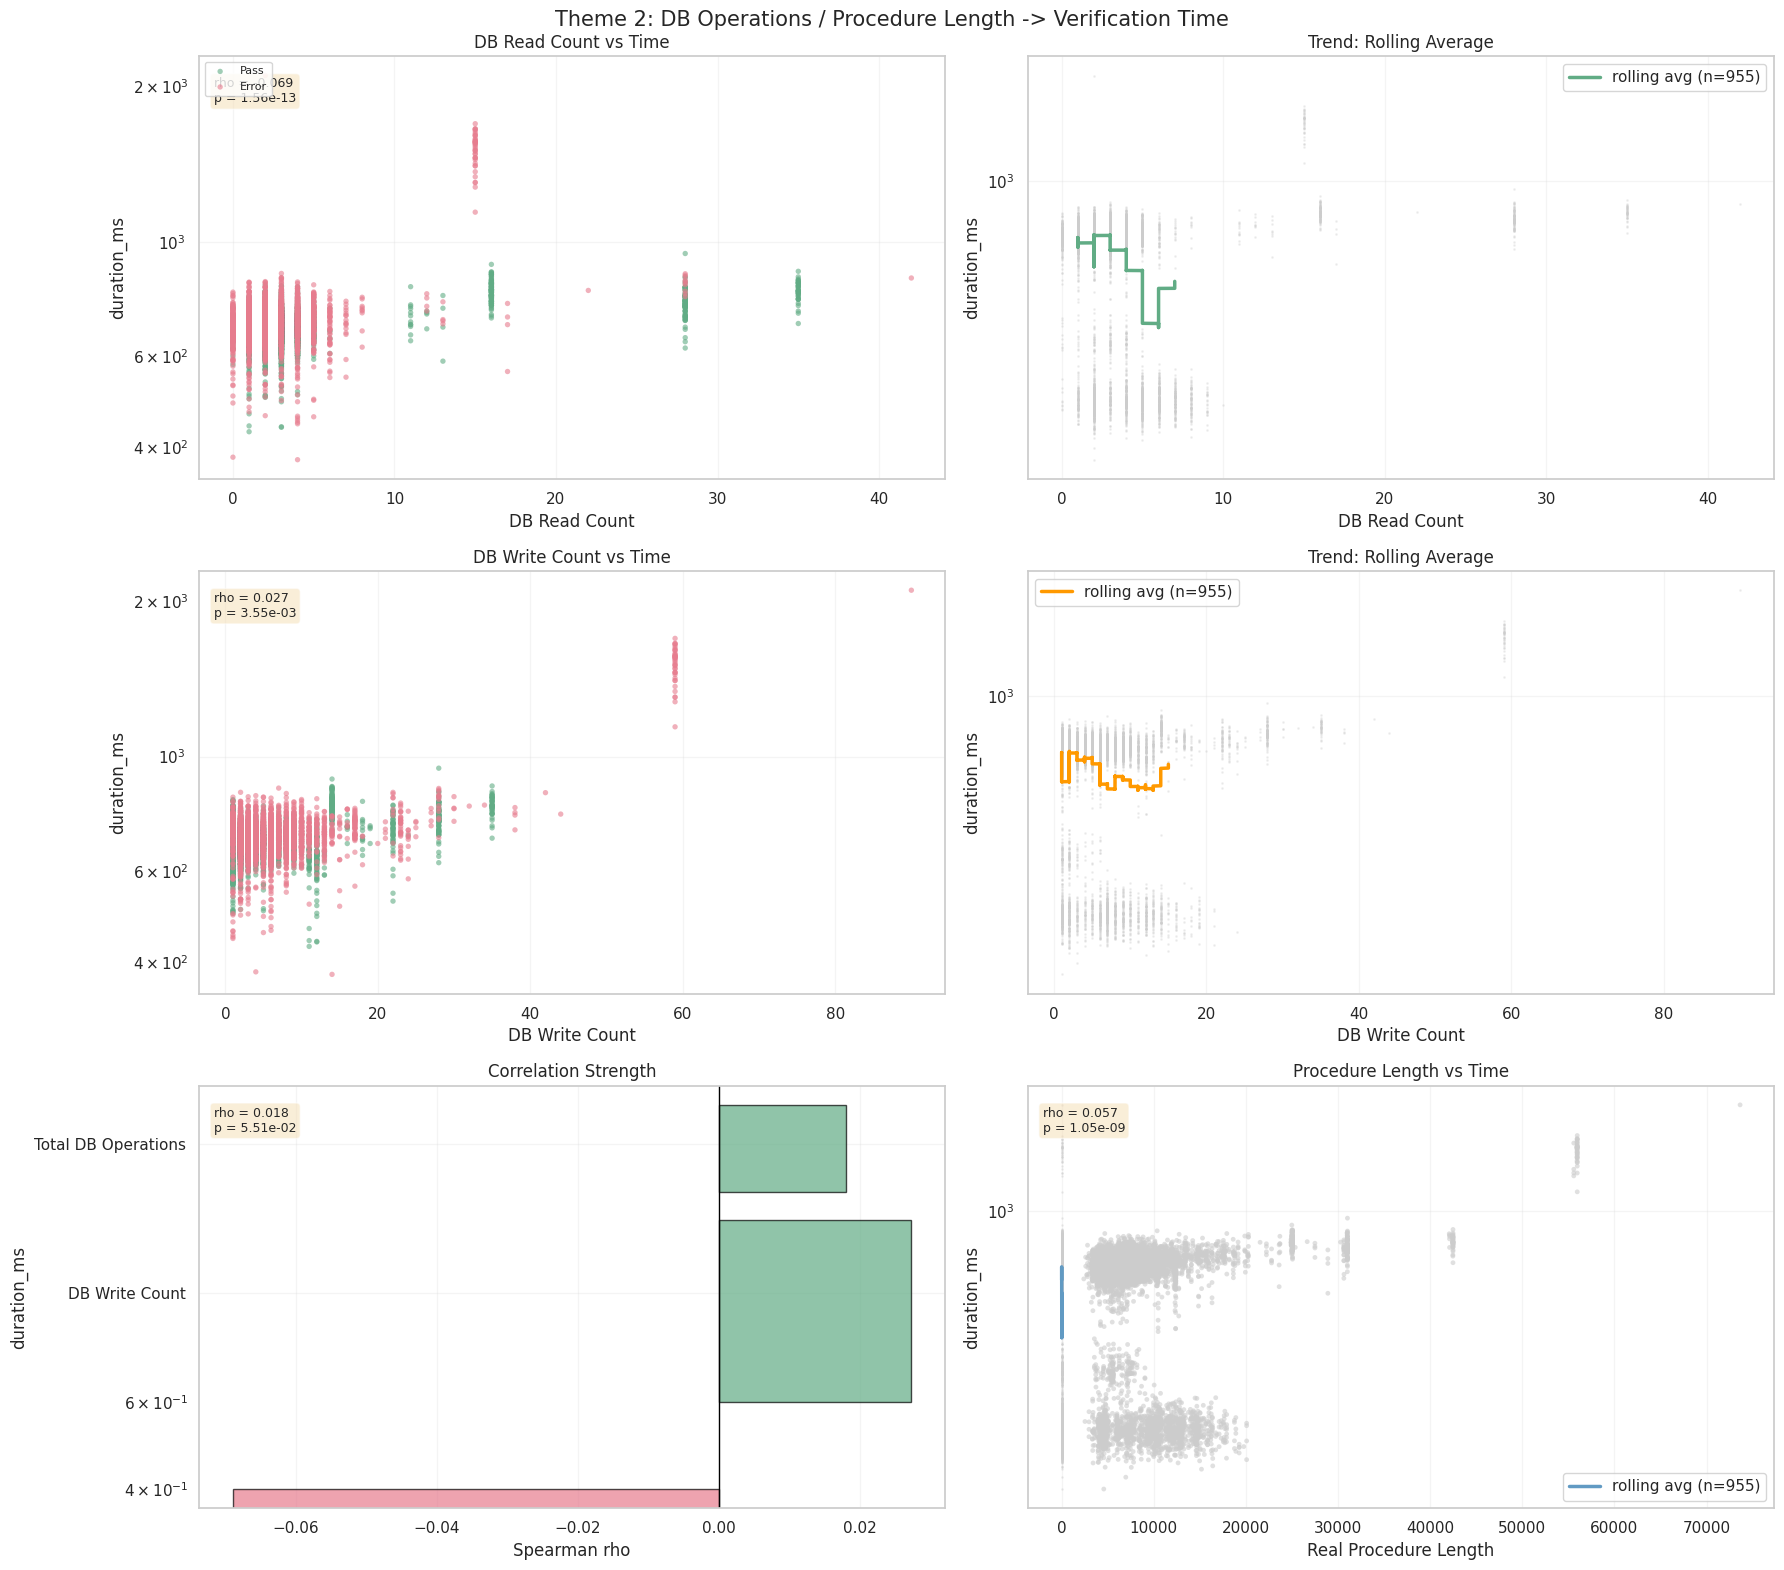

Saved /scratch/yanjunc6/FMitF_rs/tmp_plot/factor_style_plots/theme2_db_vs_time.pdf

Correlations:
  DB Read Count            : rho = -0.0689, p = 1.56e-13
  DB Write Count           : rho = 0.0272, p = 3.55e-03
  Total DB Operations      : rho = 0.0179, p = 5.51e-02


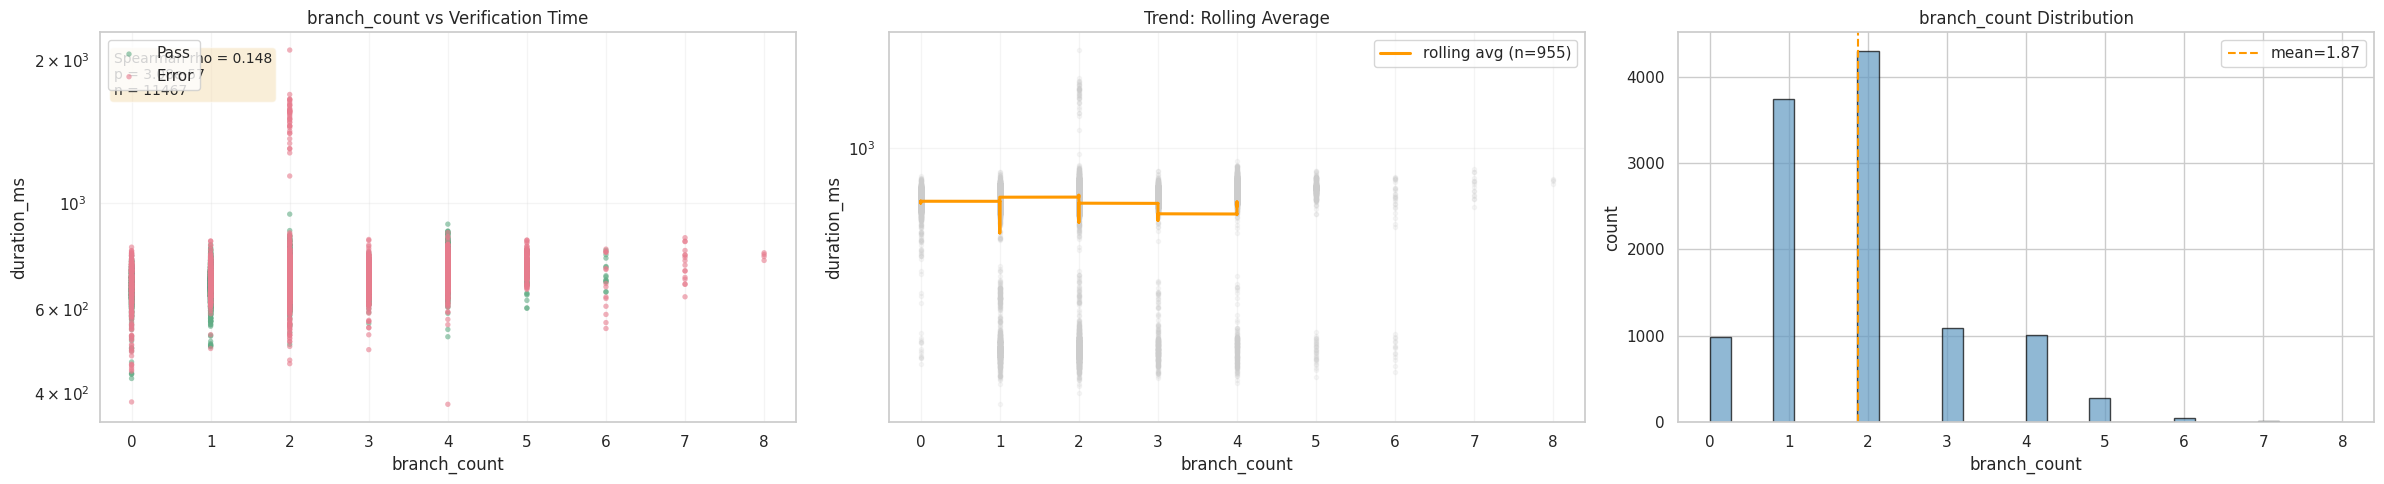

Saved /scratch/yanjunc6/FMitF_rs/tmp_plot/factor_style_plots/theme3_branch_vs_time.pdf


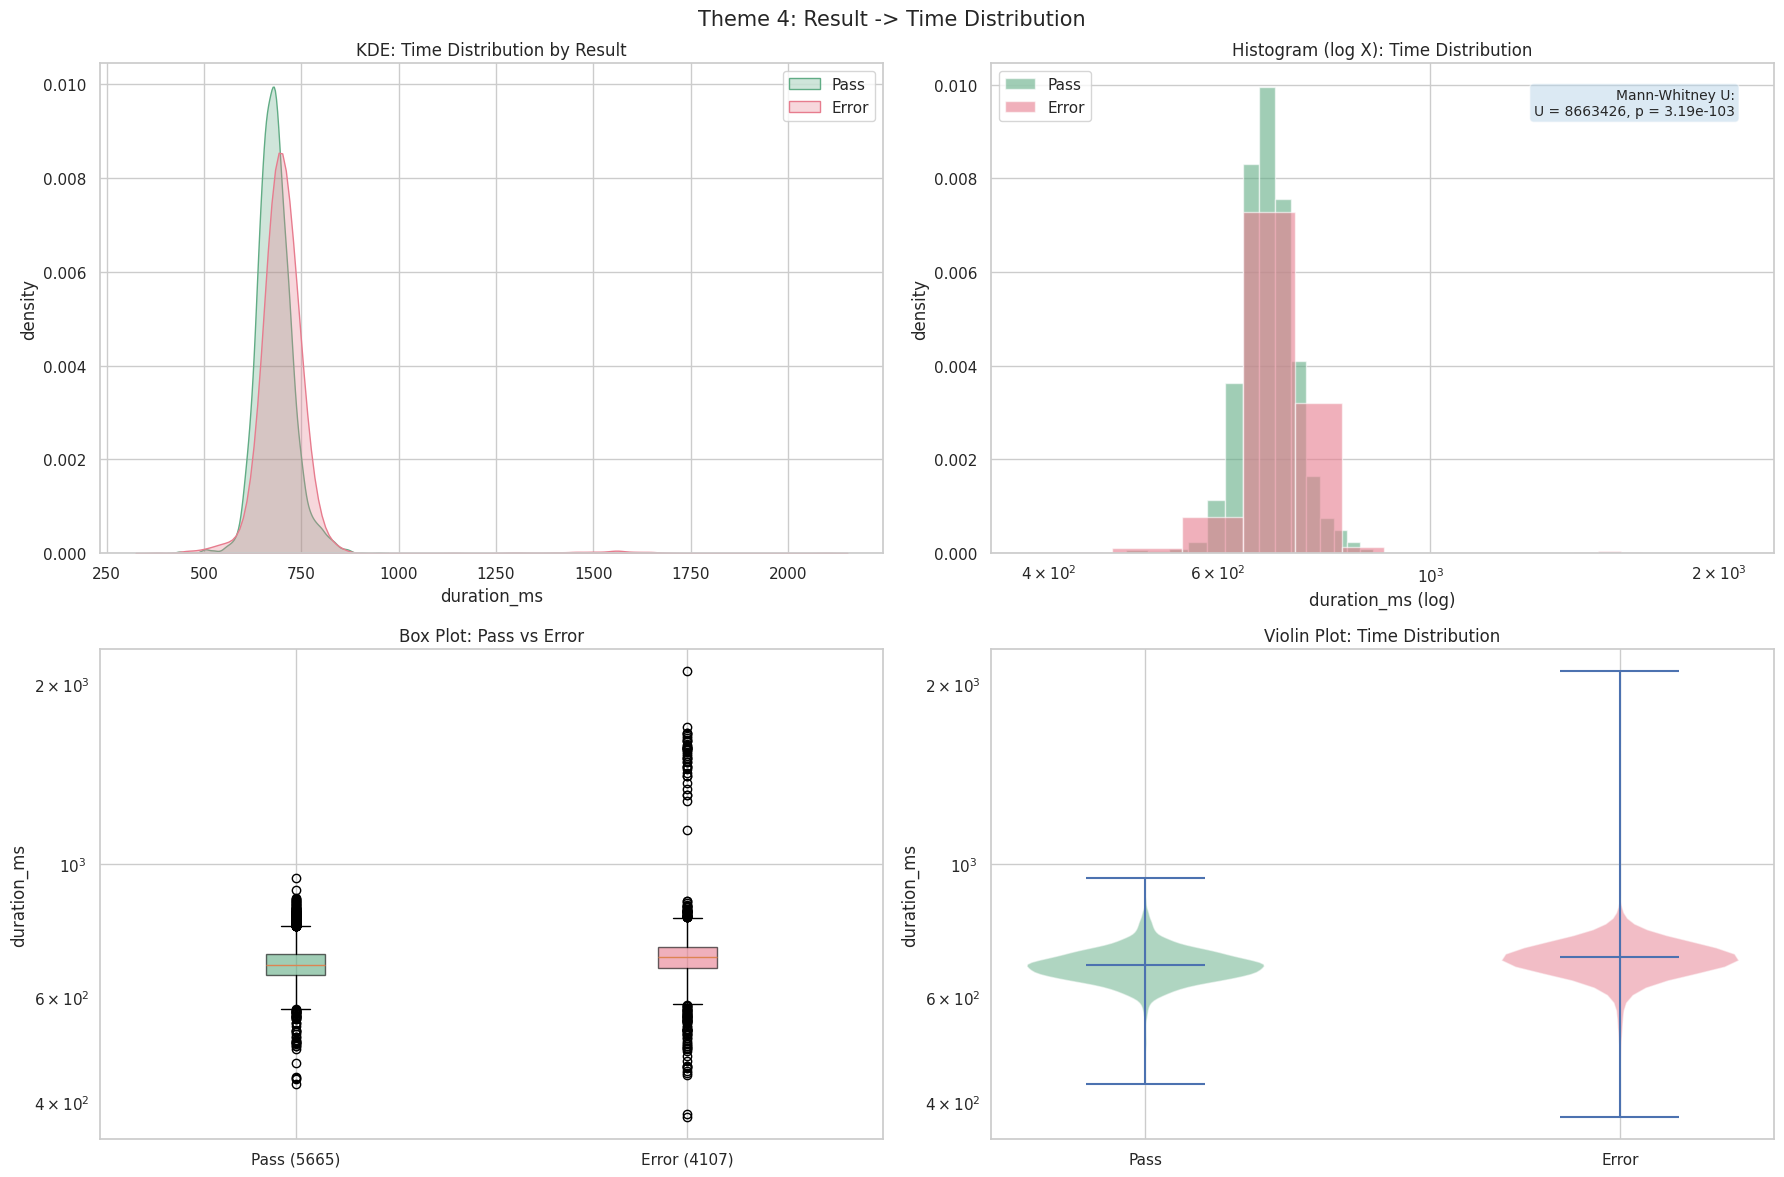

Saved /scratch/yanjunc6/FMitF_rs/tmp_plot/factor_style_plots/theme4_result_vs_time.pdf
Mann-Whitney U: U = 8663426, p = 3.19e-103
Pass:  mean=681.3ms, median=678.5ms, n=5665
Error: mean=705.9ms, median=698.6ms, n=4107


In [11]:
# Output directory for factor-style figures from benchmark_pipeline
ANALYSIS_OUT = OUTPUT_ROOT / 'factor_style_plots'
ANALYSIS_OUT.mkdir(parents=True, exist_ok=True)

print(f'Figure output directory: {ANALYSIS_OUT}')

# --- Theme 1: Boogie file length -> verification time ---
plot_factor_style_three_panel(
    df=df_all_cedge,
    x_col='boogie_file_len',
    x_label='boogie_file_len (bytes)',
    out_pdf=ANALYSIS_OUT / 'theme1_boogie_vs_time.pdf',
)

# --- Theme 2: DB operations -> verification time ---
# Match factor_analysis style with 3x2 layout.
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
db_vars = [
    ('db_read_count', 'DB Read Count'),
    ('db_write_count', 'DB Write Count'),
    ('db_total_ops', 'Total DB Operations'),
]
colors = [PASS_COLOR, ORANGE, BLUE]
correlations = {}

for row_idx, (var, label) in enumerate(db_vars):
    local = df_all_cedge[pd.notna(df_all_cedge[var]) & pd.notna(df_all_cedge['duration_ms'])]
    x = local[var]
    y = local['duration_ms']
    mask_p = local['result'] == 'Pass'
    mask_e = local['result'] == 'Error'

    axes[row_idx, 0].scatter(x[mask_p], y[mask_p], c=PASS_COLOR, alpha=POINT_ALPHA, s=15, edgecolors='none', label='Pass')
    axes[row_idx, 0].scatter(x[mask_e], y[mask_e], c=ERROR_COLOR, alpha=POINT_ALPHA, s=15, edgecolors='none', label='Error')
    axes[row_idx, 0].set_xlabel(label)
    axes[row_idx, 0].set_ylabel('duration_ms')
    axes[row_idx, 0].set_yscale('log')
    axes[row_idx, 0].grid(True, alpha=0.2)
    axes[row_idx, 0].set_title(label + ' vs Time')
    if row_idx == 0:
        axes[row_idx, 0].legend(loc='upper left', fontsize=8)

    sort_idx = np.argsort(x.values)
    x_sorted = x.values[sort_idx]
    y_sorted = y.values[sort_idx]
    window = max(3, len(local) // 12)
    rolling_mean = pd.Series(y_sorted).rolling(window=window, center=True).mean().values

    axes[row_idx, 1].plot(x_sorted, y_sorted, '.', alpha=0.25, markersize=2, color=GRAY_LIGHT)
    axes[row_idx, 1].plot(x_sorted, rolling_mean, '-', color=colors[row_idx], linewidth=2.5, label=f'rolling avg (n={window})')
    axes[row_idx, 1].set_xlabel(label)
    axes[row_idx, 1].set_ylabel('duration_ms')
    axes[row_idx, 1].set_yscale('log')
    axes[row_idx, 1].grid(True, alpha=0.2)
    axes[row_idx, 1].set_title('Trend: Rolling Average')
    axes[row_idx, 1].legend()

    rho, p, _n = _spearman_safe(x, y)
    correlations[label] = (rho, p)
    axes[row_idx, 0].text(
        0.02, 0.95,
        f'rho = {rho:.3f}\np = {p:.2e}',
        transform=axes[row_idx, 0].transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
    )

# Bottom-left: correlation bars
ax_bar = axes[2, 0]
labels = [c[1] for c in db_vars]
rhos = [correlations[l][0] for l in labels]
bar_colors = [PASS_COLOR if (not np.isnan(r) and r > 0) else ERROR_COLOR for r in rhos]
ax_bar.barh(labels, rhos, color=bar_colors, alpha=0.7, edgecolor='black')
ax_bar.axvline(x=0, color='black', linewidth=1)
ax_bar.set_xlabel('Spearman rho')
ax_bar.set_title('Correlation Strength')

# Bottom-right: procedure length relation
dp = df_all_cedge['real_procedure_len']
yd = df_all_cedge['duration_ms']
valid = dp.notna() & yd.notna()
axes[2, 1].scatter(dp[valid], yd[valid], alpha=POINT_ALPHA, s=12, color=GRAY_LIGHT, edgecolors='none')
rho_p, p_p, _n = _spearman_safe(dp, yd)
axes[2, 1].set_xlabel('Real Procedure Length')
axes[2, 1].set_ylabel('duration_ms')
axes[2, 1].set_yscale('log')
axes[2, 1].grid(True, alpha=0.2)
axes[2, 1].set_title('Procedure Length vs Time')
axes[2, 1].text(
    0.02, 0.95,
    f'rho = {rho_p:.3f}\np = {p_p:.2e}',
    transform=axes[2, 1].transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
)

fig.suptitle('Theme 2: DB Operations / Procedure Length -> Verification Time', fontsize=15, y=0.98)
fig.tight_layout()
out_theme2 = ANALYSIS_OUT / 'theme2_db_vs_time.pdf'
fig.savefig(out_theme2, dpi=150, format='pdf')
plt.show()
print(f'Saved {out_theme2}')

print('\nCorrelations:')
for label, (rho, p) in correlations.items():
    print(f'  {label:25s}: rho = {rho:.4f}, p = {p:.2e}')

# --- Theme 3: Branch count -> verification time ---
plot_factor_style_three_panel(
    df=df_all_cedge,
    x_col='branch_count',
    x_label='branch_count',
    out_pdf=ANALYSIS_OUT / 'theme3_branch_vs_time.pdf',
)

# --- Theme 4: Result (Pass/Error) -> time distribution ---
plot_result_distribution_2x2(
    df=df_all_cedge,
    out_pdf=ANALYSIS_OUT / 'theme4_result_vs_time.pdf',
)

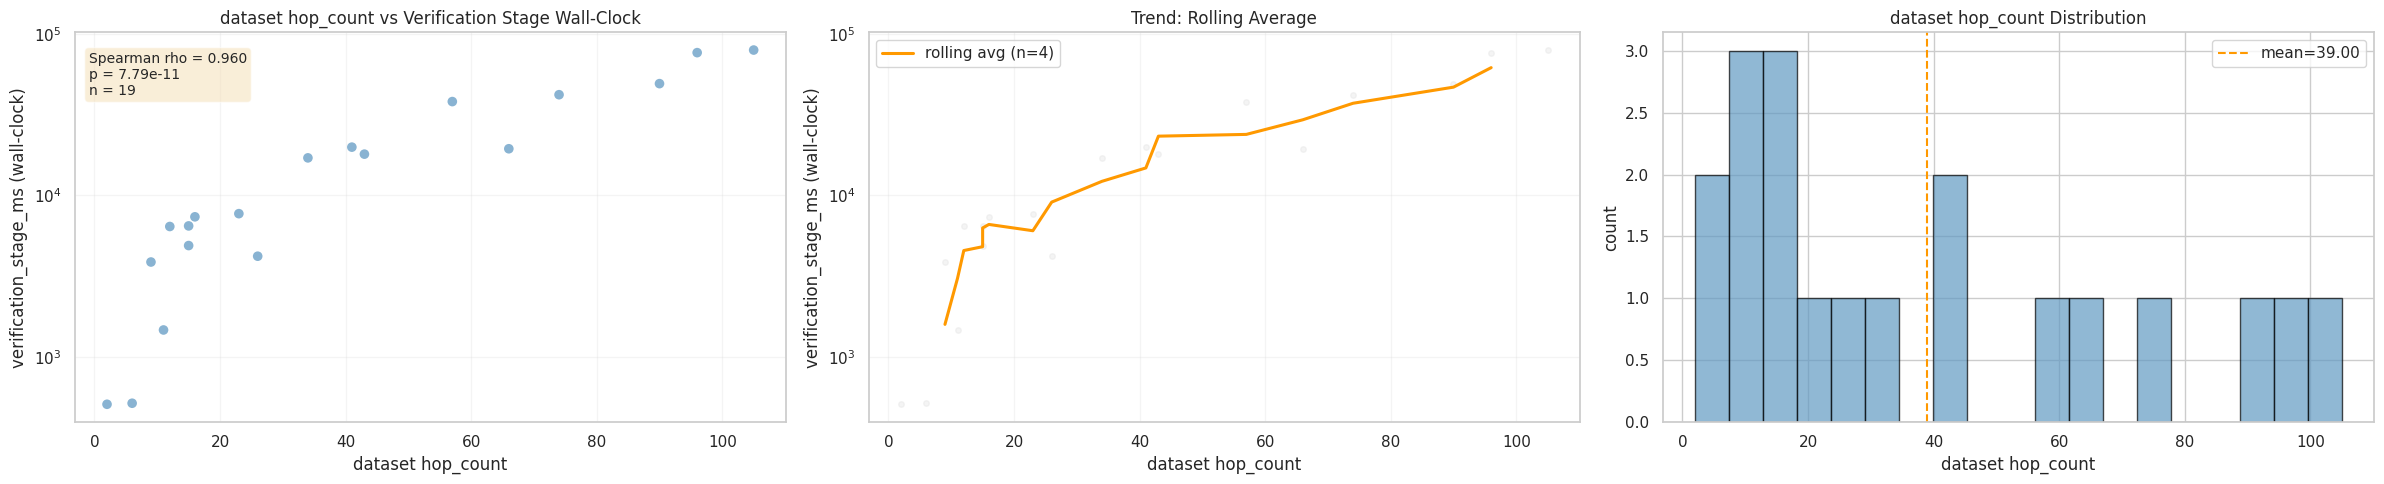

Saved /scratch/yanjunc6/FMitF_rs/tmp_plot/factor_style_plots/theme5_hop_count_vs_stage_wallclock.pdf


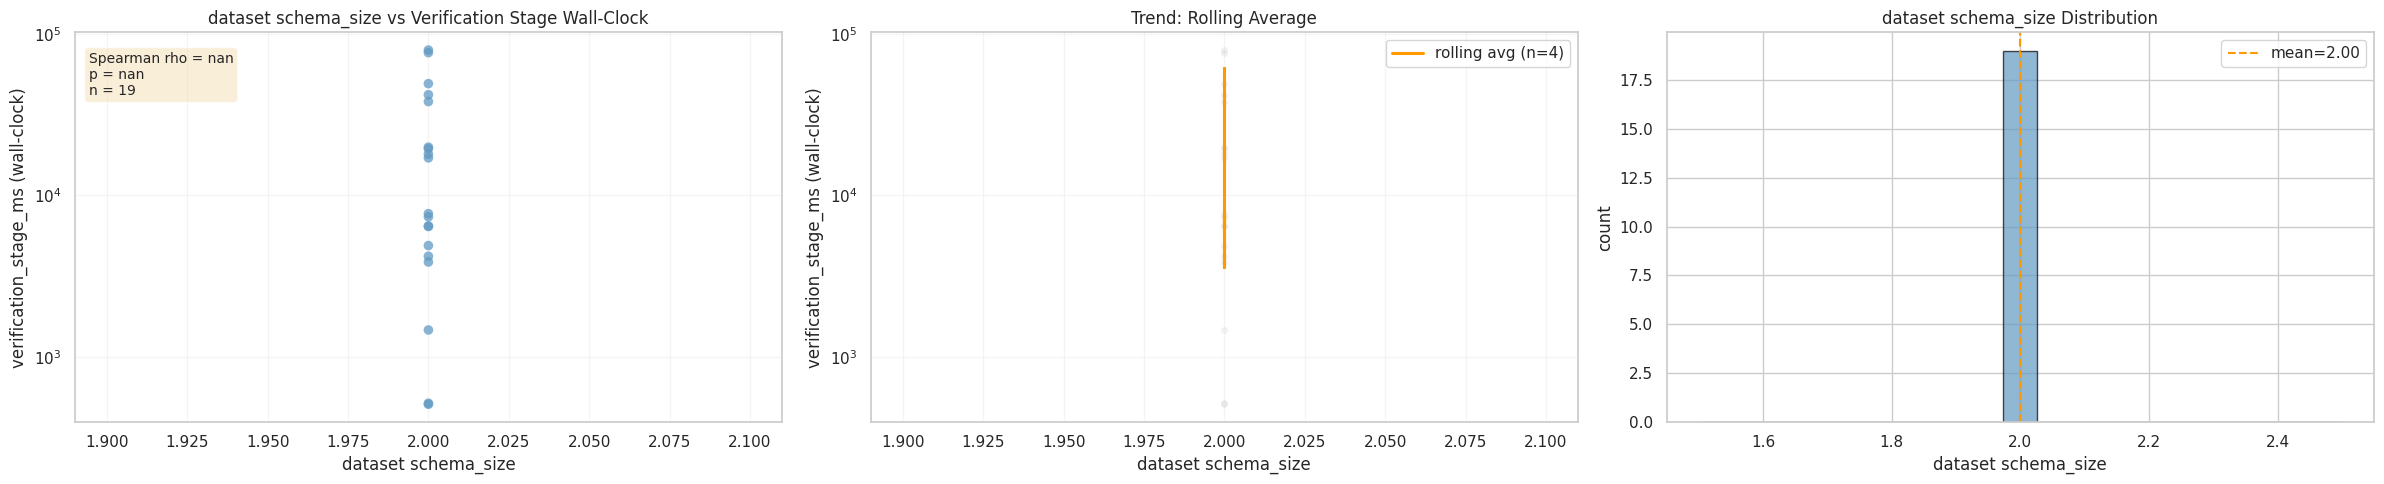

Saved /scratch/yanjunc6/FMitF_rs/tmp_plot/factor_style_plots/theme6_schema_size_vs_stage_wallclock.pdf


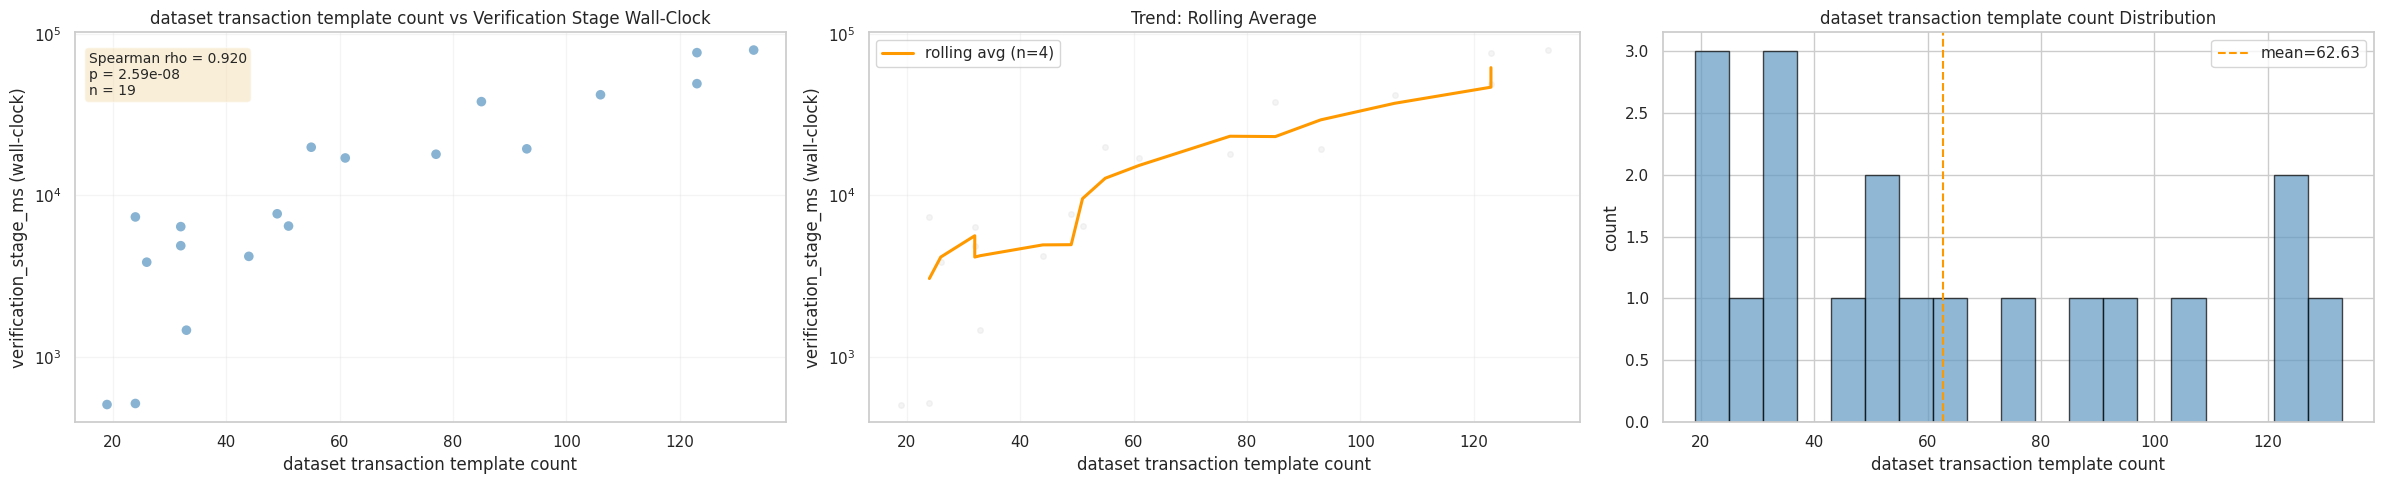

Saved /scratch/yanjunc6/FMitF_rs/tmp_plot/factor_style_plots/theme7_template_count_vs_stage_wallclock.pdf

Dataset-level summary used for extra themes (y = verification_stage_ms wall-clock):


,dataset,data_json_path,num_c_edges,verification_stage_ms,hop_count,schema_size,txn_template_count,pass_count,error_count,timeout_count,commutative_rate_pct
11,bench_100,tmp_plot/bench_100/data.json,2158,79211.221614,105.0,2.0,133.0,1482,655,0,68.674699
10,bench_090,tmp_plot/bench_090/data.json,2142,76339.042085,96.0,2.0,123.0,1372,656,0,64.052288
9,bench_080,tmp_plot/bench_080/data.json,1287,49087.584731,90.0,2.0,123.0,698,561,0,54.234654
8,bench_070,tmp_plot/bench_070/data.json,1087,41918.674363,74.0,2.0,106.0,554,533,0,50.965961
6,bench_050,tmp_plot/bench_050/data.json,1010,38011.368217,57.0,2.0,85.0,535,475,0,52.970297
16,tpcc,tmp_plot/tpcc/data.json,284,19860.062928,41.0,2.0,55.0,232,52,0,81.690141
7,bench_060,tmp_plot/bench_060/data.json,1532,19407.552987,66.0,2.0,93.0,0,0,0,0.000000
5,bench_040,tmp_plot/bench_040/data.json,454,17974.331188,43.0,2.0,77.0,195,259,0,42.951542
4,bench_030,tmp_plot/bench_030/data.json,447,17044.359764,34.0,2.0,61.0,200,247,0,44.742729
3,bench_020,tmp_plot/bench_020/data.json,191,7697.901563,23.0,2.0,49.0,78,113,0,40.837696



Saved extra-theme figures:
  - /scratch/yanjunc6/FMitF_rs/tmp_plot/factor_style_plots/theme5_hop_count_vs_stage_wallclock.pdf
  - /scratch/yanjunc6/FMitF_rs/tmp_plot/factor_style_plots/theme6_schema_size_vs_stage_wallclock.pdf
  - /scratch/yanjunc6/FMitF_rs/tmp_plot/factor_style_plots/theme7_template_count_vs_stage_wallclock.pdf


In [12]:
# --- Extra Theme A: Verification stage wall-clock as a function of hop count ---
plot_dataset_wallclock_three_panel(
    df=df_all_dataset,
    x_col='hop_count',
    x_label='dataset hop_count',
    out_pdf=ANALYSIS_OUT / 'theme5_hop_count_vs_stage_wallclock.pdf',
)

# --- Extra Theme B: Verification stage wall-clock as a function of schema size ---
plot_dataset_wallclock_three_panel(
    df=df_all_dataset,
    x_col='schema_size',
    x_label='dataset schema_size',
    out_pdf=ANALYSIS_OUT / 'theme6_schema_size_vs_stage_wallclock.pdf',
)

# --- Extra Theme C: Verification stage wall-clock as a function of transaction template count ---
plot_dataset_wallclock_three_panel(
    df=df_all_dataset,
    x_col='txn_template_count',
    x_label='dataset transaction template count',
    out_pdf=ANALYSIS_OUT / 'theme7_template_count_vs_stage_wallclock.pdf',
)

extra_summary = df_all_dataset[[
    'dataset', 'data_json_path', 'num_c_edges', 'verification_stage_ms',
    'hop_count', 'schema_size', 'txn_template_count',
    'pass_count', 'error_count', 'timeout_count', 'commutative_rate_pct',
]].sort_values('verification_stage_ms', ascending=False)

print('\nDataset-level summary used for extra themes (y = verification_stage_ms wall-clock):')
display(extra_summary)

print('\nSaved extra-theme figures:')
for p in [
    ANALYSIS_OUT / 'theme5_hop_count_vs_stage_wallclock.pdf',
    ANALYSIS_OUT / 'theme6_schema_size_vs_stage_wallclock.pdf',
    ANALYSIS_OUT / 'theme7_template_count_vs_stage_wallclock.pdf',
]:
    print(f'  - {p}')

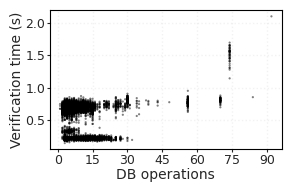

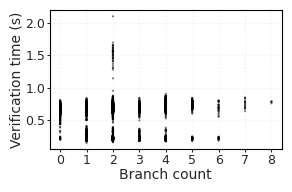

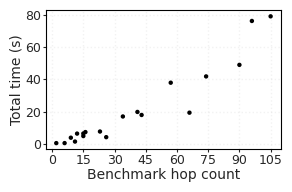

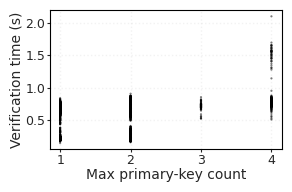

In [24]:
from matplotlib.ticker import MaxNLocator

# change to type1/truetype fonts: https://gecco-2025.sigevo.org/Paper-Submission-Instructions
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 16,
})

fig_w = 3.2                # ≈ ~1/3 A4 text width (inches)
fig_h = 2.2                # ~1/3 A4 text width (inches)

LABEL_FS = 10
TICK_FS = 9
RED = '#E77C8E'    # myred for verification time (duration)
BLUE = '#619AC3'   # myblue for verification stage time

# 1) duration_ms vs (db_read_count + db_write_count) using red small dots (no log scale)
plot1 = df_all_cedge.copy()
plot1['db_total_ops_plot'] = pd.to_numeric(plot1.get('db_read_count'), errors='coerce') + pd.to_numeric(plot1.get('db_write_count'), errors='coerce')
plot1['duration_s'] = pd.to_numeric(plot1.get('duration_ms'), errors='coerce') / 1000.0
plot1 = plot1.dropna(subset=['db_total_ops_plot', 'duration_s'])

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.scatter(
    plot1['db_total_ops_plot'],
    plot1['duration_s'],
    c='black',
    s=2.5,
    alpha=0.5,
    edgecolors='none',
)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')
ax.set_xlabel('DB operations', fontsize=LABEL_FS, labelpad=1)
ax.set_ylabel('Verification time (s)', fontsize=LABEL_FS, labelpad=1)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS, direction='out', length=2, width=0.8, pad=1)
ax.grid(True, linestyle=':', alpha=0.25)
plt.tight_layout()
plt.savefig(ANALYSIS_OUT / 'plt_db_operations_vs_verification_time.pdf', dpi=150, format='pdf')
plt.show()

# 2) branch_count vs verification time using red scatter (no log scale)
plot2 = df_all_cedge.copy()
plot2['branch_count'] = pd.to_numeric(plot2.get('branch_count'), errors='coerce')
plot2['duration_s'] = pd.to_numeric(plot2.get('duration_ms'), errors='coerce') / 1000.0
plot2 = plot2.dropna(subset=['branch_count', 'duration_s'])

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.scatter(
    plot2['branch_count'],
    plot2['duration_s'],
    c='black',
    s=2.5,
    alpha=0.5,
    edgecolors='none',
)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')
ax.set_xlabel('Branch count', fontsize=LABEL_FS, labelpad=1)
ax.set_ylabel('Verification time (s)', fontsize=LABEL_FS, labelpad=1)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS, direction='out', length=2, width=0.8, pad=1)
ax.grid(True, linestyle=':', alpha=0.25)
plt.tight_layout()
plt.savefig(ANALYSIS_OUT / 'plt_branch_count_vs_verification_time.pdf', dpi=150, format='pdf')
plt.show()

# 3) dataset hop_count vs verification_stage_ms scatter using blue
plot3 = df_all_dataset.copy()
plot3['hop_count'] = pd.to_numeric(plot3.get('hop_count'), errors='coerce')
plot3['verification_stage_s'] = pd.to_numeric(plot3.get('verification_stage_ms'), errors='coerce') / 1000.0
plot3 = plot3.dropna(subset=['hop_count', 'verification_stage_s'])

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.scatter(
    plot3['hop_count'],
    plot3['verification_stage_s'],
    c='black',
    s=10,
    alpha=1,
    edgecolors='none',
)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')
ax.set_xlabel('Benchmark hop count', fontsize=LABEL_FS, labelpad=1)
ax.set_ylabel('Total time (s)', fontsize=LABEL_FS, labelpad=1)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS, direction='out', length=2, width=0.8, pad=1)
ax.grid(True, linestyle=':', alpha=0.25)
plt.tight_layout()
plt.savefig(ANALYSIS_OUT / 'plt_hop_count_vs_verification_stage_time.pdf', dpi=150, format='pdf')
plt.show()

# 4) c-edge verification time vs max primary-key count
plot4 = df_all_cedge.copy()
plot4['max_primary_key_count'] = pd.to_numeric(plot4.get('max_primary_key_count'), errors='coerce')
plot4['duration_s'] = pd.to_numeric(plot4.get('duration_ms'), errors='coerce') / 1000.0
plot4 = plot4.dropna(subset=['max_primary_key_count', 'duration_s'])

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.scatter(
    plot4['max_primary_key_count'],
    plot4['duration_s'],
    c='black',
    s=2.5,
    alpha=0.5,
    edgecolors='none',
)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')
ax.set_xlabel('Max primary-key count', fontsize=LABEL_FS, labelpad=1)
ax.set_ylabel('Verification time (s)', fontsize=LABEL_FS, labelpad=1)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS, direction='out', length=2, width=0.8, pad=1)
ax.grid(True, linestyle=':', alpha=0.25)
plt.tight_layout()
plt.savefig(ANALYSIS_OUT / 'plt_max_pk_vs_verification_time.pdf', dpi=150, format='pdf')
plt.show()